<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/ANN_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

In [5]:
val_dataframe = dataframe.sample(frac=0.2, random_state=1337)
train_dataframe = dataframe.drop(val_dataframe.index)

print(
    "Usando %d ejemplos para entrenamiento y %d para validación"
    % (len(train_dataframe), len(val_dataframe))
)

Usando 242 ejemplos para entrenamiento y 61 para validación


In [3]:
dataframe.shape

(303, 14)

In [19]:
dataframe.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [6]:
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("target")
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds


train_ds = dataframe_to_dataset(train_dataframe)
val_ds = dataframe_to_dataset(val_dataframe)

In [11]:
for x, y in train_ds.take(1):
    display("Input:", x)
    display("Target:", y)

'Input:'

{'age': <tf.Tensor: shape=(), dtype=int64, numpy=69>,
 'sex': <tf.Tensor: shape=(), dtype=int64, numpy=1>,
 'cp': <tf.Tensor: shape=(), dtype=int64, numpy=1>,
 'trestbps': <tf.Tensor: shape=(), dtype=int64, numpy=160>,
 'chol': <tf.Tensor: shape=(), dtype=int64, numpy=234>,
 'fbs': <tf.Tensor: shape=(), dtype=int64, numpy=1>,
 'restecg': <tf.Tensor: shape=(), dtype=int64, numpy=2>,
 'thalach': <tf.Tensor: shape=(), dtype=int64, numpy=131>,
 'exang': <tf.Tensor: shape=(), dtype=int64, numpy=0>,
 'oldpeak': <tf.Tensor: shape=(), dtype=float64, numpy=0.1>,
 'slope': <tf.Tensor: shape=(), dtype=int64, numpy=2>,
 'ca': <tf.Tensor: shape=(), dtype=int64, numpy=1>,
 'thal': <tf.Tensor: shape=(), dtype=string, numpy=b'normal'>}

'Target:'

<tf.Tensor: shape=(), dtype=int64, numpy=0>

In [12]:
train_ds = train_ds.batch(32)
val_ds = val_ds.batch(32)

In [13]:
from tensorflow.keras.layers import IntegerLookup
from tensorflow.keras.layers import Normalization
from tensorflow.keras.layers import StringLookup


def encode_numerical_feature(feature, name, dataset):
    # Crear una capa de Normalización de nuestra característica
    normalizer = Normalization()

    # Preparar el Dataset solo con los campos de nuestra característica
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))

    # Encontrar las estadísticas de nuestros datos
    normalizer.adapt(feature_ds)

    # Normalizar la característica
    encoded_feature = normalizer(feature)
    return encoded_feature


def encode_categorical_feature(feature, name, dataset, is_string):
    lookup_class = StringLookup if is_string else IntegerLookup
    # Create a lookup layer which will turn strings into integer indices
    lookup = lookup_class(output_mode="binary")

    # Prepare a Dataset that only yields our feature
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))

    # Learn the set of possible string values and assign them a fixed integer index
    lookup.adapt(feature_ds)

    # Turn the string input into integer indices
    encoded_feature = lookup(feature)
    return encoded_feature

In [14]:
# Categorical features encoded as integers
sex = keras.Input(shape=(1,), name="sex", dtype="int64")
cp = keras.Input(shape=(1,), name="cp", dtype="int64")
fbs = keras.Input(shape=(1,), name="fbs", dtype="int64")
restecg = keras.Input(shape=(1,), name="restecg", dtype="int64")
exang = keras.Input(shape=(1,), name="exang", dtype="int64")
ca = keras.Input(shape=(1,), name="ca", dtype="int64")

# Categorical feature encoded as string
thal = keras.Input(shape=(1,), name="thal", dtype="string")

# Numerical features
age = keras.Input(shape=(1,), name="age")
trestbps = keras.Input(shape=(1,), name="trestbps")
chol = keras.Input(shape=(1,), name="chol")
thalach = keras.Input(shape=(1,), name="thalach")
oldpeak = keras.Input(shape=(1,), name="oldpeak")
slope = keras.Input(shape=(1,), name="slope")

all_inputs = [
    sex,
    cp,
    fbs,
    restecg,
    exang,
    ca,
    thal,
    age,
    trestbps,
    chol,
    thalach,
    oldpeak,
    slope,
]

# Integer categorical features
sex_encoded = encode_categorical_feature(sex, "sex", train_ds, False)
cp_encoded = encode_categorical_feature(cp, "cp", train_ds, False)
fbs_encoded = encode_categorical_feature(fbs, "fbs", train_ds, False)
restecg_encoded = encode_categorical_feature(restecg, "restecg", train_ds, False)
exang_encoded = encode_categorical_feature(exang, "exang", train_ds, False)
ca_encoded = encode_categorical_feature(ca, "ca", train_ds, False)

# String categorical features
thal_encoded = encode_categorical_feature(thal, "thal", train_ds, True)

# Numerical features
age_encoded = encode_numerical_feature(age, "age", train_ds)
trestbps_encoded = encode_numerical_feature(trestbps, "trestbps", train_ds)
chol_encoded = encode_numerical_feature(chol, "chol", train_ds)
thalach_encoded = encode_numerical_feature(thalach, "thalach", train_ds)
oldpeak_encoded = encode_numerical_feature(oldpeak, "oldpeak", train_ds)
slope_encoded = encode_numerical_feature(slope, "slope", train_ds)

all_features = layers.concatenate(
    [
        sex_encoded,
        cp_encoded,
        fbs_encoded,
        restecg_encoded,
        exang_encoded,
        slope_encoded,
        ca_encoded,
        thal_encoded,
        age_encoded,
        trestbps_encoded,
        chol_encoded,
        thalach_encoded,
        oldpeak_encoded,
    ]
)
x = layers.Dense(32, activation="relu")(all_features)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(all_inputs, output)
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

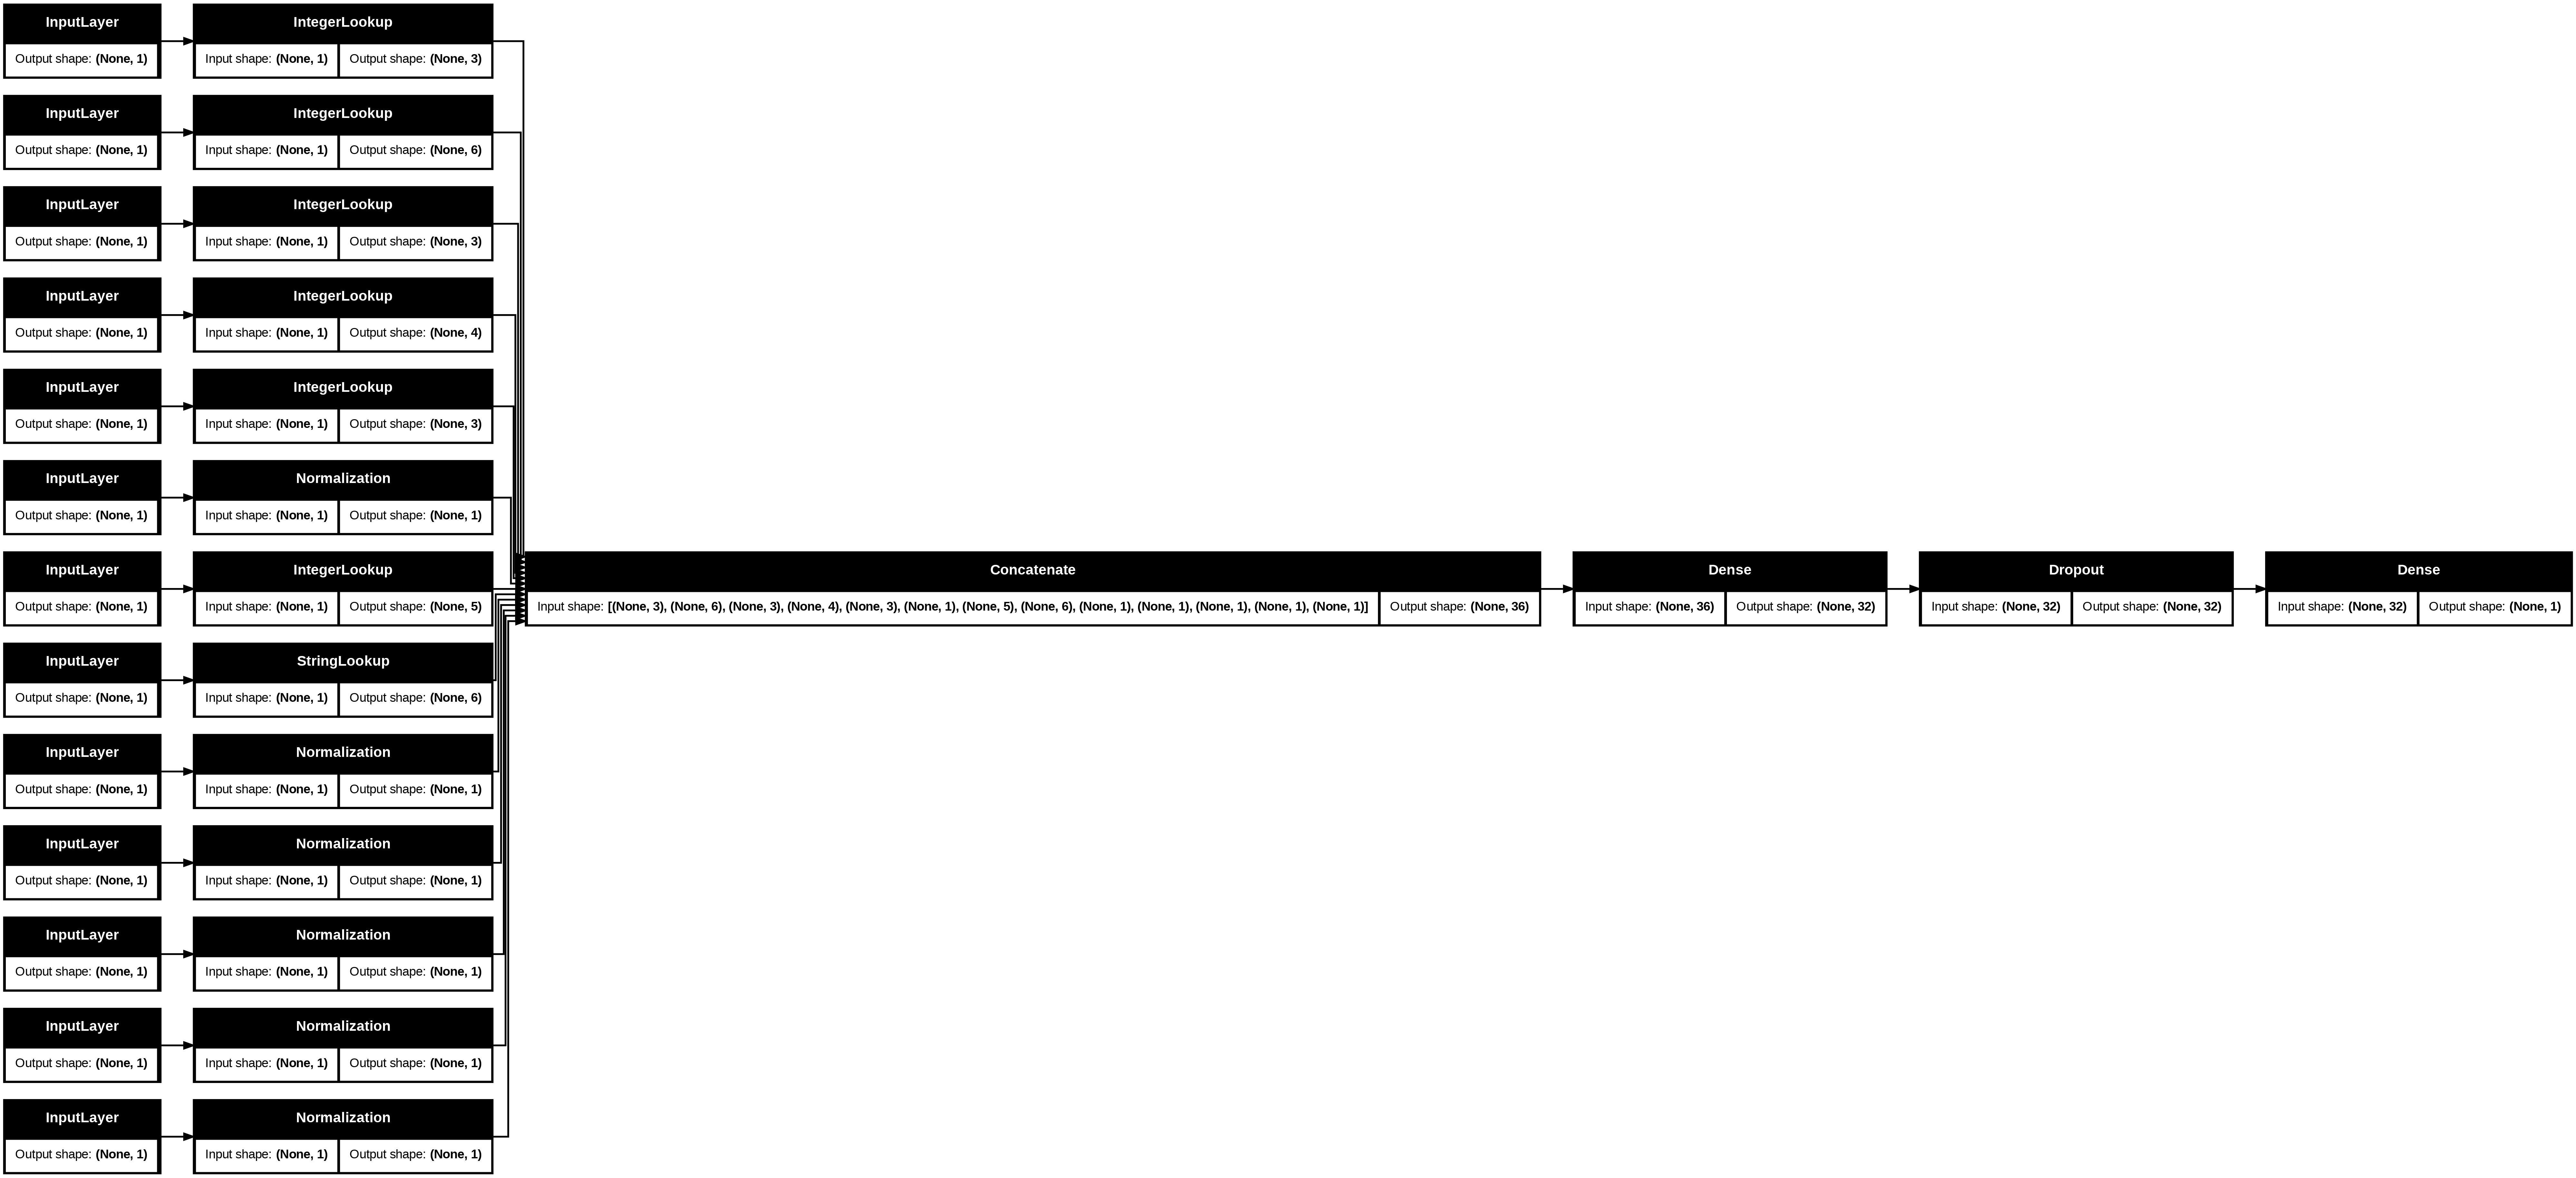

In [15]:
# `rankdir='LR'` is to make the graph horizontal.
keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [16]:
model.fit(train_ds, epochs=100, validation_data=val_ds)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.4951 - loss: 0.7454 - val_accuracy: 0.5738 - val_loss: 0.6681
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6117 - loss: 0.6868 - val_accuracy: 0.7049 - val_loss: 0.6153
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6613 - loss: 0.6350 - val_accuracy: 0.7869 - val_loss: 0.5734
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7036 - loss: 0.5994 - val_accuracy: 0.8197 - val_loss: 0.5382
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7585 - loss: 0.5377 - val_accuracy: 0.7869 - val_loss: 0.5070
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7773 - loss: 0.5122 - val_accuracy: 0.7705 - val_loss: 0.4819
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7635 - loss: 0.5228 - val_accuracy: 0.7869 - val_loss: 0.4628
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7303 - loss: 0.5125 - val_accuracy: 0.7705 - val_loss: 0.4463

In [18]:
sample = {
    "age": 67,
    "sex": 1,
    "cp": 4,
    "trestbps": 160,
    "chol": 286,
    "fbs": 0,
    "restecg": 2,
    "thalach": 108,
    "exang": 1,
    "oldpeak": 1.5,
    "slope": 2,
    "ca": 3,
    "thal": "normal",
}

input_dict = {name: tf.convert_to_tensor([value]) for name, value in sample.items()}
predictions = model.predict(input_dict)

print(
    "El paciente en particular tiene un %.1f de probabilidad"
    "de sufrir un problema cardíaco con base en nuestro modelo. " % (100 * predictions[0][0],)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
El paciente en particular tiene un 70.3 de probabilidadde sufrir un problema cardíaco con base en nuestro modelo. 
